In [1]:
%load_ext autoreload
%autoreload 2 

In [ ]:
from image import Image, slice_and_save
from processor import PlaneMask, PlaneProjection
import os
import json
import matplotlib.pyplot as plt
from cells import RBCellMask, RBClusters, ClusterCountMask, save_clusters
import numpy as np

In [ ]:
slice_and_save() # Slice images into 500x500 patches for better analysis
# slice_and_save(output_dir='data/sliced-1000', width = 1000)

# Load all images from a directory
imgs = Image.from_dir('data/sliced')

np.random.seed(42)
# Take 5 random images and save RBC all clusters as individual images
save_clusters(imgs, 5) 
# Or A specific image
save_clusters(Image.from_path('data/sliced/I_37550251_1500_2000.jpg'))

Images chosen: ['I_37550251_2000_500', 'I_42757274_500_500', 'I_42757274_500_2000', 'I_37550251_1500_1500', 'I_42757274_2000_500']
Images chosen: ['I_37550251_1500_2000']
[13]


Selected index: 44. Selected image: I_42757274_2000_500 (is test: False)


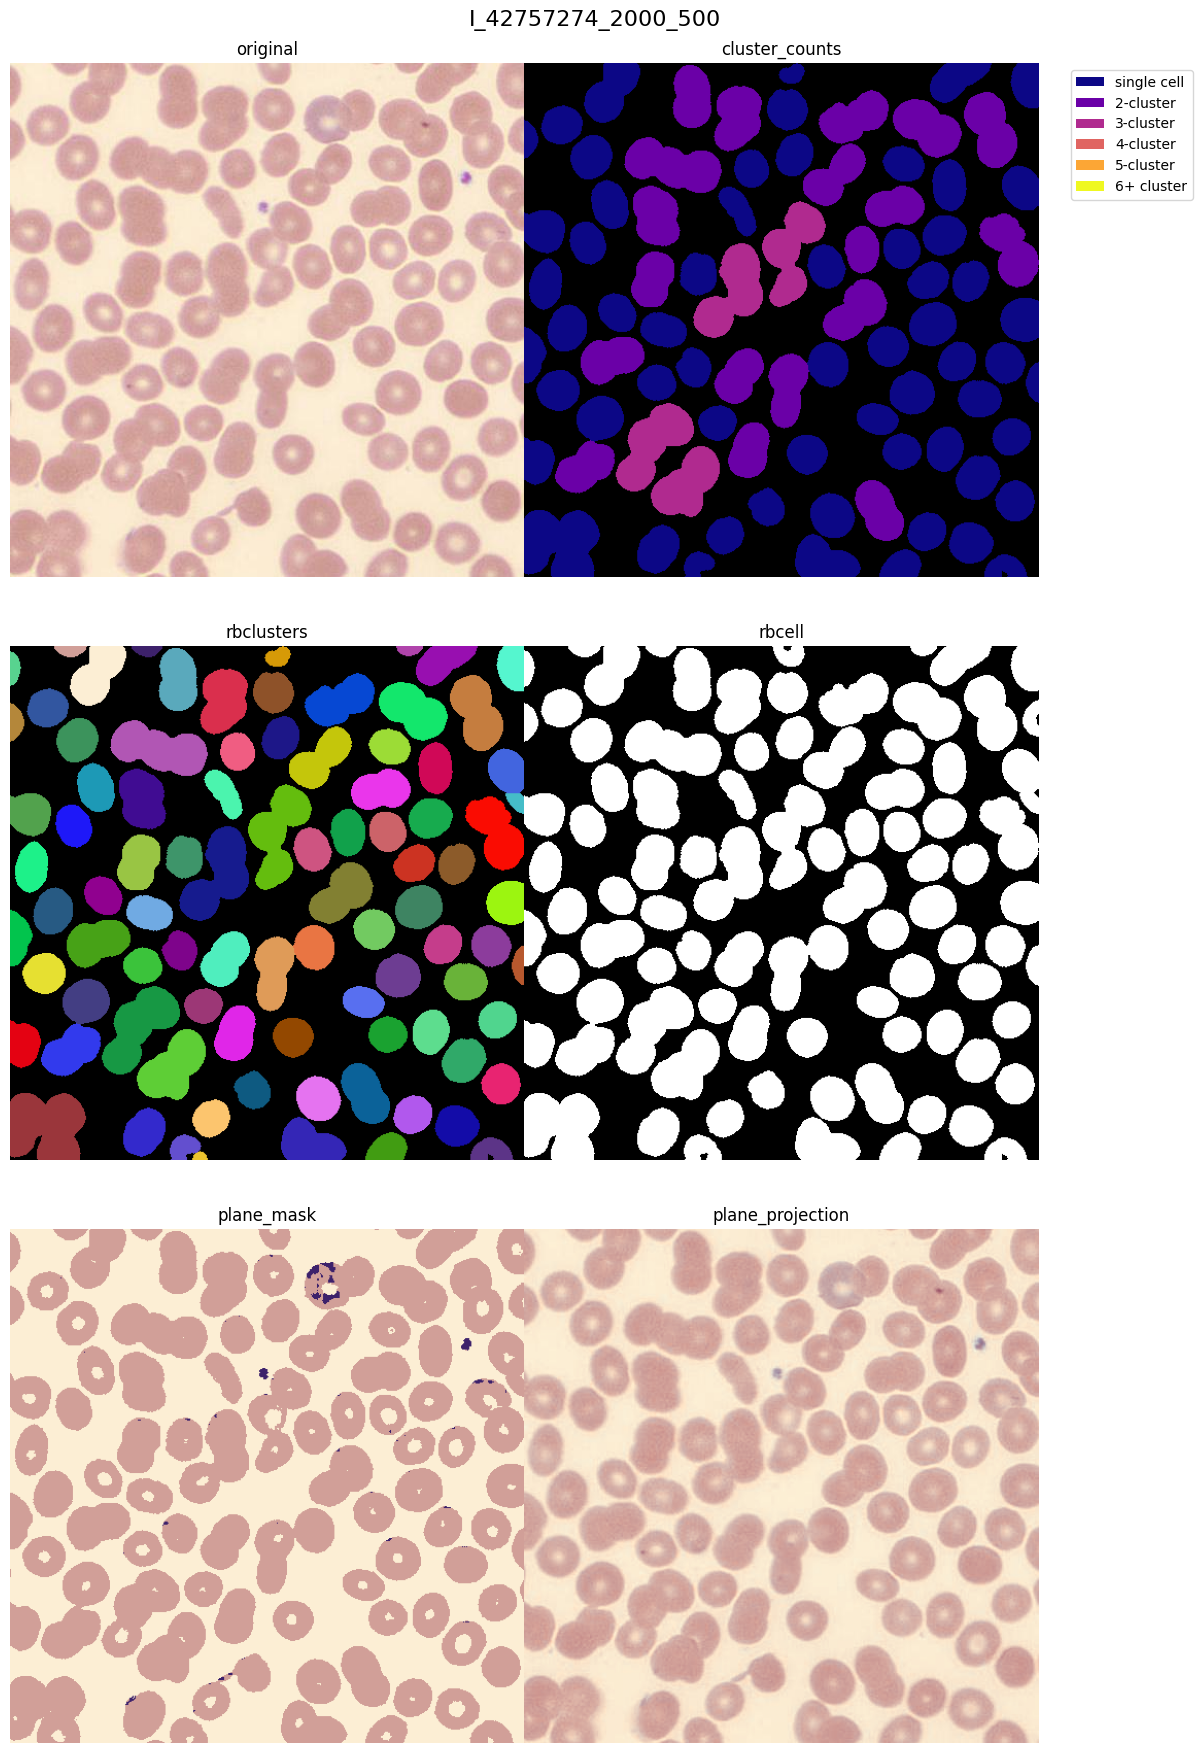

In [ ]:
# Pipeline Tutorial

# Step 1: Get some Image instance from imgs or loading a specific file
idx = np.random.randint(len(imgs))
# idx = 57
img = imgs[idx]
# img = Image.from_path('data/sliced-1000/I_42757274_1000_0.jpg')
print(f'Selected index: {idx or None}. Selected image: {img.title} (is test: {'test' in img.title})')

# Step 2: Create some filters using a color configuration (see the available jsons)
config_path = 'configs/triangle.json' if 'test' not in img.title \
    else 'configs/triangle-lab2.json' 
mask_proj = PlaneProjection.from_json(config_path)
mask_plane = PlaneMask.from_json(config_path)
mask_rbc = RBCellMask.from_json(config_path)
mask_clusters = RBClusters.from_json(config_path)
mask_counts = ClusterCountMask.from_json(config_path)

# Step 3: Apply each filter to the image. 
#   The filtered image is also accesible through the original image, as seen below
img0_proj = mask_proj.process(img)
img0_plane = mask_plane.process(img)
img0_rbc = mask_rbc.process(img)
img0_clusters = mask_clusters.process(img)
img_counts = mask_counts.process(img)
    
# Step 4: Show the image versions side by side
img.show_versions([
    'original',         # Unedited format
    'cluster_counts',   # ClusterCountMask
    'rbclusters',       # RBClusters
    'rbcell',           # RBCellMask
    'plane_mask',       # PlaneMask
    'plane_projection', # PlaneProjection
])

plt.show()


442
Total clusters: 442. Total cells: 429
Cluster sensitivity: 90.41%
Cluster precision: 92.96%
Cluster specificity: 98.60%
Cluster errors: MAE 0.05, MSE: 0.05


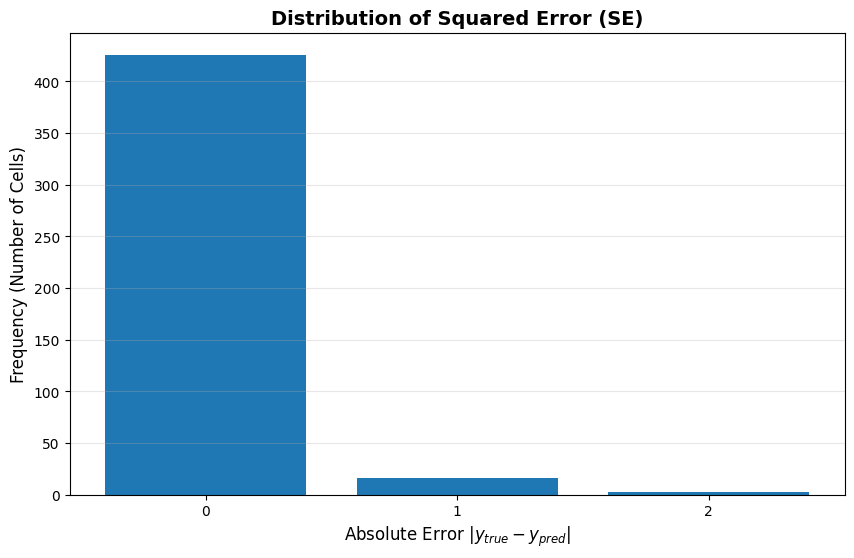

In [5]:
def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

preds:dict[str, list[int]] = load_json('data/test/labels.json')
labels:dict[str, list[int]] = load_json('data/test/labels-manual.json')

tp = 0
tn = 0
fp = 0
fn = 0
n_clusters = 0
SE = []
AE = []
for pcluster in preds:
    if pcluster not in labels:
        continue
    n_clusters+= 1
    
    label = labels[pcluster]
    pred = preds[pcluster][0]

    # 1. Add square errors:
    SE += [(i-pred)**2 for i in label]
    AE += [abs(i-pred) for i in label]

    # 2. Add cluster precisions:
    pos = len([i for i in label if i >= 2])
    neg = sum([i for i in label if i == 1])

    if pred >= 2: # positives
        tp += pos
        fp += neg
    else: # negatives
        tn += neg
        fn += pos
n_cells = tp+fp+tn+fn
MSE = sum(SE)/len(SE)
MAE = sum(AE)/len(SE)

cluster_specifity = tn/(tn+fp)
cluster_sensitivity = tp/(tp+fn)
cluster_precision = tp / (tp+ fp)

print(len(labels))
print(f"Total clusters: {n_clusters}. Total cells: {n_cells}")
print(f'Cluster sensitivity: {cluster_sensitivity*100:.2f}%')
print(f'Cluster precision: {cluster_precision*100:.2f}%')
print(f'Cluster specificity: {cluster_specifity*100:.2f}%')
print(f'Cluster errors: MAE {MAE:.2f}, MSE: {MSE:.2f}')

plt.figure(figsize=(10,6))
ns = [int(i) for i in AE]
bins = np.arange(min(ns), max(ns) + 2) - 0.5
plt.hist(AE, bins, rwidth=0.8)
plt.title('Distribution of Squared Error (SE)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Error $|y_{true} - y_{pred}|$', fontsize=12)
plt.ylabel('Frequency (Number of Cells)', fontsize=12)
plt.xticks(np.unique(AE))
plt.grid(axis='y', alpha=0.3)
plt.show()